# Explore here

In [249]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import spotipy 
from spotipy.oauth2 import SpotifyClientCredentials



In [250]:
# load the .env file variables
load_dotenv()

client_id = os.environ.get("CLIENT_ID")
client_secret = os.environ.get("CLIENT_SECRET")

In [251]:
sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
    client_id=client_id,
    client_secret=client_secret
))

In [252]:
artista = sp.artist('3jO7X5KupvwmWTHGtHgcgo')
print(artista['name'])


Charly García


In [253]:
#Top 10 canciones
top = sp.artist_top_tracks('3jO7X5KupvwmWTHGtHgcgo', country='AR')
tracks_top = []
for track in top['tracks']:
    tracks_top.append({
        'name': track['name']
    })

tracks_top

[{'name': 'Nos Siguen Pegando Abajo'},
 {'name': 'Demoliendo Hoteles'},
 {'name': 'No Voy en Tren'},
 {'name': 'Promesas Sobre El Bidet'},
 {'name': 'Hablando a Tu Corazón'},
 {'name': 'No Me Dejan Salir'},
 {'name': 'Raros Peinados Nuevos'},
 {'name': 'Tu Amor'},
 {'name': 'Rezo por Vos'},
 {'name': 'Los Dinosaurios'}]

In [254]:
#Top 10 canciones jutno a la popularidad y duracion en ms
tracks_info = []
for track in top['tracks']:
    tracks_info.append({
        'name': track['name'],
        'popularidad': track['popularity'],
        'duracion': track['duration_ms']
    })
df = pd.DataFrame(tracks_info)

df

,name,popularidad,duracion
0,Nos Siguen Pegando Abajo,67,206720
1,Demoliendo Hoteles,66,135973
2,No Voy en Tren,63,181600
3,Promesas Sobre El Bidet,64,164360
4,Hablando a Tu Corazón,63,255266
5,No Me Dejan Salir,62,263200
6,Raros Peinados Nuevos,60,214760
7,Tu Amor,60,186466
8,Rezo por Vos,59,269053
9,Los Dinosaurios,57,208093


In [255]:
# pasar la duracion a minutos
df['duracion (m)'] = ((df['duracion'] / 1000) / 60).round(2)

df = df.drop('duracion', axis=1)
print(df)

                       name  popularidad  duracion (m)
0  Nos Siguen Pegando Abajo           67          3.45
1        Demoliendo Hoteles           66          2.27
2            No Voy en Tren           63          3.03
3   Promesas Sobre El Bidet           64          2.74
4     Hablando a Tu Corazón           63          4.25
5         No Me Dejan Salir           62          4.39
6     Raros Peinados Nuevos           60          3.58
7                   Tu Amor           60          3.11
8              Rezo por Vos           59          4.48
9           Los Dinosaurios           57          3.47


In [256]:
# Ordenalas en orden ascendente y muestra las 3 primeras
menos_populares = df.sort_values(by='popularidad', ascending=True)

(menos_populares).head(3)

,name,popularidad,duracion (m)
9,Los Dinosaurios,57,3.47
8,Rezo por Vos,59,4.48
6,Raros Peinados Nuevos,60,3.58


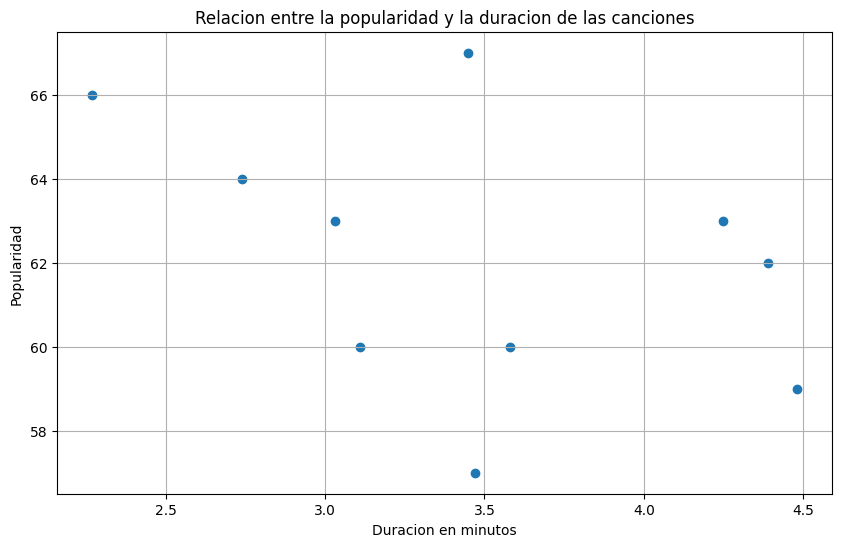

In [257]:
# Analisis graficando un scatter plot 

plt.figure(figsize=(10, 6))
plt.scatter(df['duracion (m)'], df['popularidad'])

plt.xlabel('Duracion en minutos')
plt.ylabel('Popularidad')
plt.title('Relacion entre la popularidad y la duracion de las canciones')
plt.grid(True)
plt.show()

# Conclusion
Como se muestra en el grafico no se aprecia una relacion clara entre la duracion y la popularidad de una cancion, quizas deberiamos hacer el mismo grafico con mas canciones. En mi opininon esto depende mas del artista, de la cancion en si independientemente de lo que dure y tambien del marketing que haya recibido una cancion

In [258]:
# A partir de aqui ya no me lee

tracks_audio = []
top = sp.artist_top_tracks('3jO7X5KupvwmWTHGtHgcgo', country='AR')

for track in top['tracks']:
    tracks_audio.append({
        'name': track['id']
    })
tracks_audio




[{'name': '4VikOud5ZmdmHH6h7uQeDB'},
 {'name': '29iIRrSuANyjnwag69PHOJ'},
 {'name': '0rliTXrA8nLBuJcxDuueWU'},
 {'name': '2MXqrO1RBfek6RoijghYYp'},
 {'name': '3k9dGCm2R2Y70e87aMHYC3'},
 {'name': '6P6rudfmKr7FyArdyEs0Mk'},
 {'name': '7mnf5omGMUwSfpwZrt5AZ0'},
 {'name': '3obYcaXHdTB1EvZE3PVQhd'},
 {'name': '6dOzqs6o4DNzXs4jF2v1Yq'},
 {'name': '3VCKdfJAL8DTDlwZw5O6Ik'}]